# Corpus Quality Analysis for Processed Chunk Files

This notebook scales chunk-quality testing from a single processed JSON file to the **entire processed corpus**.

## When to use it
Run this notebook **after text processing** and **before Pinecone indexing**.

## What it checks
- schema completeness
- chunk size / word count / duration sanity
- timestamp validity
- duplicate chunk IDs
- duplicate exact chunk text
- per-video chunk statistics
- corpus-level summary and a readiness decision

It is designed to work on all processed files matching:

`../data/processed/chunks_timestamped_*.json`

In [1]:
import os
import json
import glob
import hashlib
from datetime import datetime
from collections import Counter

import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

## Configuration
Adjust thresholds here if needed.

In [2]:
PROCESSED_DIR = "../data/processed"
CHUNK_GLOB = "chunks_timestamped_*.json"

# Quality thresholds
MIN_CHARS = 200
MAX_CHARS = 1500
MIN_WORDS = 30
MAX_WORDS = 300
MIN_DURATION_SEC = 15
MAX_DURATION_SEC = 180

# Output reports
# REPORT_JSON = "quality_report_corpus.json"
# VIDEO_CSV = "quality_report_videos.csv"
# CHUNK_CSV = "quality_report_chunks.csv"
# ISSUES_CSV = "quality_report_issues.csv"

## Discover processed chunk files

In [3]:
chunk_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, CHUNK_GLOB)))
print(f"Found {len(chunk_files)} processed chunk file(s)")

chunk_files[:10]

Found 25 processed chunk file(s)


['../data/processed\\chunks_timestamped_04K0bLwCDdM.json',
 '../data/processed\\chunks_timestamped_1YTKedLQOa0.json',
 '../data/processed\\chunks_timestamped_21G7LA2DcGQ.json',
 '../data/processed\\chunks_timestamped_78K0pbvHzjM.json',
 '../data/processed\\chunks_timestamped_AkX6JqlWRqc.json',
 '../data/processed\\chunks_timestamped_Bls5KnQOWkY.json',
 '../data/processed\\chunks_timestamped_C-FEVzI8oe8.json',
 '../data/processed\\chunks_timestamped_DLE-ieOVFjI.json',
 '../data/processed\\chunks_timestamped_GHjopp47vvQ.json',
 '../data/processed\\chunks_timestamped_Hn_iozUo9m4.json']

## Load all processed chunks into memory

In [4]:
all_chunks = []
file_level_summary = []

for path in chunk_files:
    with open(path, "r", encoding="utf-8") as f:
        chunks = json.load(f)

    file_video_id = chunks[0].get("video_id") if chunks else None

    file_level_summary.append({
        "file_path": path,
        "video_id": file_video_id,
        "chunk_count": len(chunks),
    })

    all_chunks.extend(chunks)

print(f"Loaded {len(all_chunks)} chunk(s) in total")
print(f"Loaded {len(file_level_summary)} file-level record(s)")

Loaded 295 chunk(s) in total
Loaded 25 file-level record(s)


## Normalize chunk records for analysis

In [5]:
def safe_len_words(text):
    return len((text or "").split())

def md5_text(text):
    return hashlib.md5((text or "").strip().encode("utf-8")).hexdigest()

normalized_chunks = []

for chunk in all_chunks:
    metadata = chunk.get("metadata", {}) or {}
    text = chunk.get("text", "") or ""

    normalized_chunks.append({
        "chunk_id": chunk.get("chunk_id"),
        "video_id": chunk.get("video_id"),
        "video_title": chunk.get("video_title"),
        "channel": chunk.get("channel"),
        "video_url": chunk.get("video_url"),
        "chunk_index": chunk.get("chunk_index"),
        "total_chunks": chunk.get("total_chunks"),
        "text": text,
        "char_count": chunk.get("char_count", len(text)),
        "word_count": chunk.get("word_count", safe_len_words(text)),
        "start_time": chunk.get("start_time"),
        "end_time": chunk.get("end_time"),
        "duration_seconds": chunk.get("duration_seconds"),
        "source_segment_count": chunk.get("source_segment_count"),
        "source_segments": chunk.get("source_segments"),
        "transcript_language": metadata.get("transcript_language"),
        "transcript_status": metadata.get("transcript_status"),
        "video_duration": metadata.get("video_duration"),
        "upload_date": metadata.get("upload_date"),
        "view_count": metadata.get("view_count"),
        "like_count": metadata.get("like_count"),
        "comment_count": metadata.get("comment_count"),
        "categories": metadata.get("categories"),
        "tags": metadata.get("tags"),
        "text_hash": md5_text(text),
    })

if pd is not None:
    df_chunks = pd.DataFrame(normalized_chunks)
    display(df_chunks.head())
else:
    df_chunks = None
    print(normalized_chunks[:2])

,chunk_id,video_id,video_title,channel,video_url,chunk_index,total_chunks,text,char_count,word_count,...,transcript_language,transcript_status,video_duration,upload_date,view_count,like_count,comment_count,categories,tags,text_hash
0,04K0bLwCDdM_chunk_0000,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,https://www.youtube.com/watch?v=04K0bLwCDdM,0,20,The development of composite materials over th...,1178,182,...,en,ok,1415,20230912,519694,13783,302,[Education],"[materials, composites, CFRP, carbon fiber, ca...",d586e35b7b13800266088dd8f552c054
1,04K0bLwCDdM_chunk_0001,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,https://www.youtube.com/watch?v=04K0bLwCDdM,1,20,"In most composites, one material, called the d...",1189,181,...,en,ok,1415,20230912,519694,13783,302,[Education],"[materials, composites, CFRP, carbon fiber, ca...",133ed0920e84ae97e7d902b4cdcc73e9
2,04K0bLwCDdM_chunk_0002,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,https://www.youtube.com/watch?v=04K0bLwCDdM,2,20,Probably the most widely used composite materi...,1139,177,...,en,ok,1415,20230912,519694,13783,302,[Education],"[materials, composites, CFRP, carbon fiber, ca...",dfd0b909a296c24a0968c2b2ca50c5de
3,04K0bLwCDdM_chunk_0003,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,https://www.youtube.com/watch?v=04K0bLwCDdM,3,20,Any fiber-reinforced material that has fibers ...,1194,205,...,en,ok,1415,20230912,519694,13783,302,[Education],"[materials, composites, CFRP, carbon fiber, ca...",06b70eb90da70a6181266dcd3713b851
4,04K0bLwCDdM_chunk_0004,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,https://www.youtube.com/watch?v=04K0bLwCDdM,4,20,This is why components made from fiber-reinfor...,1191,194,...,en,ok,1415,20230912,519694,13783,302,[Education],"[materials, composites, CFRP, carbon fiber, ca...",d29e4e8b034195b02c913dc9717b4374


## Validate schema and chunk quality

In [6]:
issues = []

def add_issue(level, issue_type, video_id=None, chunk_id=None, detail=None):
    issues.append({
        "level": level,
        "issue_type": issue_type,
        "video_id": video_id,
        "chunk_id": chunk_id,
        "detail": detail,
    })

for row in normalized_chunks:
    video_id = row["video_id"]
    chunk_id = row["chunk_id"]
    text = row["text"] or ""

    if not row["chunk_id"]:
        add_issue("error", "missing_chunk_id", video_id, chunk_id)

    if not row["video_id"]:
        add_issue("error", "missing_video_id", video_id, chunk_id)

    if not text.strip():
        add_issue("error", "empty_text", video_id, chunk_id)

    if row["char_count"] is None:
        add_issue("error", "missing_char_count", video_id, chunk_id)
    else:
        if row["char_count"] < MIN_CHARS:
            add_issue("warning", "chunk_too_short_chars", video_id, chunk_id, row["char_count"])
        if row["char_count"] > MAX_CHARS:
            add_issue("warning", "chunk_too_long_chars", video_id, chunk_id, row["char_count"])

    if row["word_count"] is None:
        add_issue("error", "missing_word_count", video_id, chunk_id)
    else:
        if row["word_count"] < MIN_WORDS:
            add_issue("warning", "chunk_too_short_words", video_id, chunk_id, row["word_count"])
        if row["word_count"] > MAX_WORDS:
            add_issue("warning", "chunk_too_long_words", video_id, chunk_id, row["word_count"])

    st = row["start_time"]
    et = row["end_time"]
    dur = row["duration_seconds"]

    if st is None or et is None:
        add_issue("error", "missing_time_range", video_id, chunk_id)
    elif et < st:
        add_issue("error", "invalid_time_range", video_id, chunk_id, f"{st} -> {et}")

    if dur is None:
        add_issue("warning", "missing_duration_seconds", video_id, chunk_id)
    else:
        if dur < MIN_DURATION_SEC:
            add_issue("warning", "chunk_too_short_duration", video_id, chunk_id, dur)
        if dur > MAX_DURATION_SEC:
            add_issue("warning", "chunk_too_long_duration", video_id, chunk_id, dur)

    source_segments = row["source_segments"]
    if not isinstance(source_segments, list) or len(source_segments) == 0:
        add_issue("error", "missing_source_segments", video_id, chunk_id)

    if row["source_segment_count"] is None:
        add_issue("warning", "missing_source_segment_count", video_id, chunk_id)

    if row["transcript_status"] not in [None, "ok"]:
        add_issue("warning", "non_ok_transcript_status", video_id, chunk_id, row["transcript_status"])

print(f"Validation finished. Total issues found: {len(issues)}")

Validation finished. Total issues found: 0


## Duplicate checks

In [7]:
if pd is not None:
    dup_chunk_ids = df_chunks[df_chunks.duplicated(subset=["chunk_id"], keep=False)].copy()
    dup_text_hash = df_chunks[df_chunks.duplicated(subset=["text_hash"], keep=False)].copy()
    dup_text_exact = df_chunks[df_chunks.duplicated(subset=["text"], keep=False)].copy()
else:
    dup_chunk_ids = []
    dup_text_hash = []
    dup_text_exact = []

print("Duplicate chunk_ids:", 0 if pd is None else dup_chunk_ids["chunk_id"].nunique())
print("Duplicate exact-text groups:", 0 if pd is None else dup_text_hash["text_hash"].nunique())

Duplicate chunk_ids: 0
Duplicate exact-text groups: 0


## Per-video aggregation

In [8]:
if pd is not None and not df_chunks.empty:
    video_stats = (
        df_chunks.groupby("video_id", dropna=False)
        .agg(
            video_title=("video_title", "first"),
            channel=("channel", "first"),
            total_chunks=("chunk_id", "count"),
            total_words=("word_count", "sum"),
            total_chars=("char_count", "sum"),
            avg_chunk_words=("word_count", "mean"),
            avg_chunk_chars=("char_count", "mean"),
            min_chunk_chars=("char_count", "min"),
            max_chunk_chars=("char_count", "max"),
            min_start_time=("start_time", "min"),
            max_end_time=("end_time", "max"),
            avg_chunk_duration=("duration_seconds", "mean"),
            transcript_language=("transcript_language", "first"),
            transcript_status=("transcript_status", "first"),
            video_duration=("video_duration", "first"),
        )
        .reset_index()
    )

    display(video_stats.head())
else:
    video_stats = None
    print("No DataFrame available for per-video aggregation.")

,video_id,video_title,channel,total_chunks,total_words,total_chars,avg_chunk_words,avg_chunk_chars,min_chunk_chars,max_chunk_chars,min_start_time,max_end_time,avg_chunk_duration,transcript_language,transcript_status,video_duration
0,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,20,3677,23176,183.850000,1158.800000,943,1198,0.180,1409.460,81.588200,en,ok,1415
1,1YTKedLQOa0,Understanding Torsion,The Efficient Engineer,9,1754,9616,194.888889,1068.444444,454,1194,0.540,605.840,75.964333,en,ok,615
2,21G7LA2DcGQ,Understanding Buckling,The Efficient Engineer,12,2299,13809,191.583333,1150.750000,944,1193,1.359,886.041,81.447750,en,ok,888
3,78K0pbvHzjM,Understanding Plane Stress,The Efficient Engineer,4,690,3972,172.500000,993.000000,451,1195,0.030,247.400,68.842500,en,ok,250
4,AkX6JqlWRqc,Understanding True Stress and True Strain,The Efficient Engineer,6,1032,6254,172.000000,1042.333333,393,1197,0.179,400.919,74.943833,en,ok,410


## Issue summary

In [9]:
if pd is not None:
    df_issues = pd.DataFrame(issues)
    if not df_issues.empty:
        issue_summary = (
            df_issues.groupby(["level", "issue_type"])
            .size()
            .reset_index(name="count")
            .sort_values(["level", "count"], ascending=[True, False])
        )
        display(issue_summary)
    else:
        df_issues = pd.DataFrame(columns=["level", "issue_type", "video_id", "chunk_id", "detail"])
        print("No issues found.")
else:
    df_issues = None
    print(Counter(i["issue_type"] for i in issues))

No issues found.


## Corpus-level summary and readiness decision

In [10]:
corpus_summary = {
    "generated_at": datetime.now().isoformat(),
    "processed_dir": PROCESSED_DIR,
    "files_found": len(chunk_files),
    "total_chunks": len(normalized_chunks),
    "total_videos": len(set(r["video_id"] for r in normalized_chunks if r["video_id"])),
    "total_words": int(sum(r["word_count"] or 0 for r in normalized_chunks)),
    "total_chars": int(sum(r["char_count"] or 0 for r in normalized_chunks)),
    "duplicate_chunk_ids": int(0 if pd is None else dup_chunk_ids["chunk_id"].nunique()),
    "duplicate_exact_text_groups": int(0 if pd is None else dup_text_hash["text_hash"].nunique()),
    "total_issues": len(issues),
    "issue_counts": dict(Counter(i["issue_type"] for i in issues)),
}

def rate_corpus(summary):
    total_chunks = summary["total_chunks"]
    dup_ids = summary["duplicate_chunk_ids"]
    total_issues = summary["total_issues"]

    if total_chunks < 50:
        return "needs_more_data"
    if dup_ids > 0:
        return "fix_duplicates_before_indexing"
    if total_issues > max(10, int(0.05 * total_chunks)):
        return "fix_quality_issues_before_indexing"
    return "ready_for_embedding_and_indexing"

decision = rate_corpus(corpus_summary)

print("Decision:", decision)
corpus_summary

Decision: ready_for_embedding_and_indexing


{'generated_at': '2026-03-06T14:11:52.280237',
 'processed_dir': '../data/processed',
 'files_found': 25,
 'total_chunks': 295,
 'total_videos': 25,
 'total_words': 56311,
 'total_chars': 336260,
 'duplicate_chunk_ids': 0,
 'duplicate_exact_text_groups': 0,
 'total_issues': 0,
 'issue_counts': {}}

## Save reports

In [11]:
# report_path = os.path.join(PROCESSED_DIR, REPORT_JSON)
# with open(report_path, "w", encoding="utf-8") as f:
#     json.dump(
#         {
#             "summary": corpus_summary,
#             "decision": decision,
#             "issues": issues,
#         },
#         f,
#         indent=2,
#         ensure_ascii=False,
#     )

# print("Saved JSON report:", report_path)

# if pd is not None:
#     if video_stats is not None:
#         video_stats.to_csv(os.path.join(PROCESSED_DIR, VIDEO_CSV), index=False)
#     df_chunks.to_csv(os.path.join(PROCESSED_DIR, CHUNK_CSV), index=False)
#     pd.DataFrame(issues).to_csv(os.path.join(PROCESSED_DIR, ISSUES_CSV), index=False)
#     print("Saved CSV reports")

## Optional charts

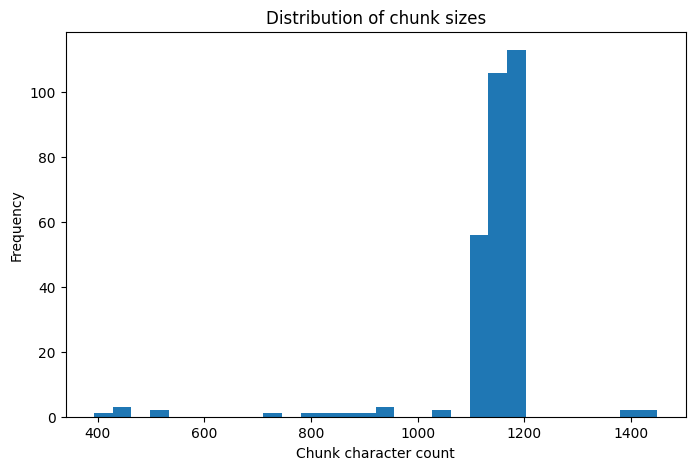

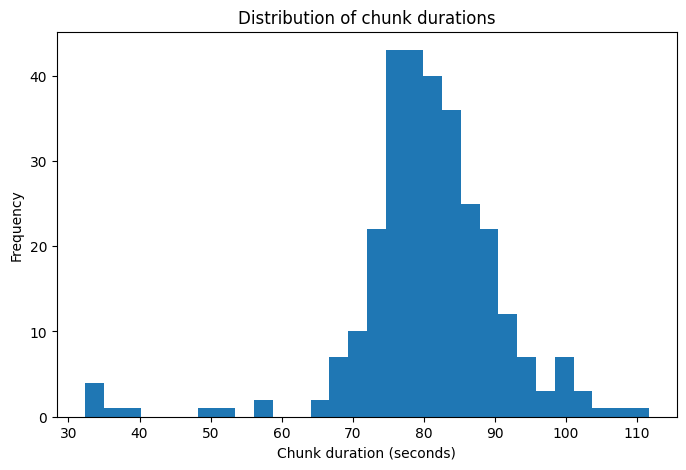

In [13]:
if plt is not None and pd is not None and not df_chunks.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(df_chunks["char_count"].dropna(), bins=30)
    plt.xlabel("Chunk character count")
    plt.ylabel("Frequency")
    plt.title("Distribution of chunk sizes")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df_chunks["duration_seconds"].dropna(), bins=30)
    plt.xlabel("Chunk duration (seconds)")
    plt.ylabel("Frequency")
    plt.title("Distribution of chunk durations")
    plt.show()
else:
    print("matplotlib or pandas not available, or no data to plot.")

## Inspect duplicates if any

In [14]:
if pd is not None:
    print("Duplicate chunk IDs:")
    display(dup_chunk_ids[["chunk_id", "video_id", "video_title", "chunk_index"]].head(20))

    print("Duplicate exact chunk text:")
    display(dup_text_exact[["video_id", "video_title", "chunk_id", "chunk_index", "text"]].head(20))

Duplicate chunk IDs:


,chunk_id,video_id,video_title,chunk_index


Duplicate exact chunk text:


,video_id,video_title,chunk_id,chunk_index,text


## Inspect problematic videos

In [15]:
if pd is not None and df_issues is not None and not df_issues.empty:
    issues_per_video = (
        df_issues.groupby("video_id")
        .size()
        .reset_index(name="issue_count")
        .sort_values("issue_count", ascending=False)
    )
    display(issues_per_video.head(20))
else:
    print("No issue table available.")

No issue table available.


In [16]:
print("\n" + "=" * 80)
print("RAG QUALITY ASSESSMENT")
print("=" * 80)

# Compute corpus stats from df_chunks
total_chunks = len(df_chunks)
total_words = int(df_chunks["word_count"].sum())
chunk_sizes = df_chunks["char_count"].dropna().tolist()
total_videos = df_chunks["video_id"].nunique()

# Industry-style benchmarks
benchmarks = {
    "min_chunks": 50,
    "good_chunks": 100,
    "excellent_chunks": 200,
    "min_words": 10000,
    "good_words": 20000,
    "excellent_words": 40000,
    "min_chunk_size": 200,
    "max_chunk_size": 1500,
    "good_videos": 10,
    "excellent_videos": 25,
}

print("\n📊 Your Dataset vs Benchmarks:\n")

def assess(value, min_val, good_val, name, excellent_val=None):
    if excellent_val is not None and value >= excellent_val:
        status = "✅ EXCELLENT"
    elif value >= good_val:
        status = "🟢 STRONG"
    elif value >= min_val:
        status = "🟡 GOOD"
    else:
        status = "⚠️ NEEDS MORE"

    print(f"  {name}: {value:,} {status}")
    if excellent_val is not None:
        print(f"    Benchmark: Min={min_val:,}, Good={good_val:,}, Excellent={excellent_val:,}")
    else:
        print(f"    Benchmark: Min={min_val:,}, Good={good_val:,}")

    return value >= min_val

checks = []
checks.append(
    assess(
        total_chunks,
        benchmarks["min_chunks"],
        benchmarks["good_chunks"],
        "Total Chunks",
        benchmarks["excellent_chunks"],
    )
)

checks.append(
    assess(
        total_words,
        benchmarks["min_words"],
        benchmarks["good_words"],
        "Total Words",
        benchmarks["excellent_words"],
    )
)

checks.append(
    assess(
        total_videos,
        5,
        benchmarks["good_videos"],
        "Total Videos",
        benchmarks["excellent_videos"],
    )
)

avg_chunk_size = float(np.mean(chunk_sizes)) if chunk_sizes else 0
print(f"\n  Avg Chunk Size: {avg_chunk_size:.0f} chars", end=" ")
if benchmarks["min_chunk_size"] <= avg_chunk_size <= benchmarks["max_chunk_size"]:
    print("✅ OPTIMAL")
    checks.append(True)
else:
    print("⚠️ SUBOPTIMAL")
    checks.append(False)

print(f"    Optimal Range: {benchmarks['min_chunk_size']}-{benchmarks['max_chunk_size']} chars")

# Additional useful corpus stats
median_chunk_size = float(np.median(chunk_sizes)) if chunk_sizes else 0
chunks_per_video = df_chunks.groupby("video_id").size()
avg_chunks_per_video = float(chunks_per_video.mean()) if len(chunks_per_video) else 0

print(f"\n  Median Chunk Size: {median_chunk_size:.0f} chars")
print(f"  Avg Chunks per Video: {avg_chunks_per_video:.1f}")
print(f"  Min Chunks in a Video: {int(chunks_per_video.min()) if len(chunks_per_video) else 0}")
print(f"  Max Chunks in a Video: {int(chunks_per_video.max()) if len(chunks_per_video) else 0}")

# Issue-aware adjustment
issue_penalty = 0
if 'df_issues' in globals() and not df_issues.empty:
    error_count = int((df_issues["level"] == "error").sum())
    warning_count = int((df_issues["level"] == "warning").sum())
    print(f"\n  Errors Found: {error_count}")
    print(f"  Warnings Found: {warning_count}")

    if error_count > 0:
        issue_penalty += 2
    elif warning_count > max(10, total_chunks * 0.05):
        issue_penalty += 1

print("\n" + "=" * 80)
score = sum(checks) - issue_penalty

if score >= 4:
    print("✅ OVERALL: Your dataset is GOOD for RAG")
    print("   You have sufficient chunked content for a solid chatbot knowledge base.")
elif score >= 2:
    print("🟡 OVERALL: Your dataset is ACCEPTABLE for RAG")
    print("   It should work, but adding more videos or improving chunk quality would help.")
else:
    print("⚠️ OVERALL: Your dataset NEEDS MORE WORK")
    print("   Improve chunk quality and/or add more source material before indexing.")
print("=" * 80)


RAG QUALITY ASSESSMENT

📊 Your Dataset vs Benchmarks:

  Total Chunks: 295 ✅ EXCELLENT
    Benchmark: Min=50, Good=100, Excellent=200
  Total Words: 56,311 ✅ EXCELLENT
    Benchmark: Min=10,000, Good=20,000, Excellent=40,000
  Total Videos: 25 ✅ EXCELLENT
    Benchmark: Min=5, Good=10, Excellent=25

  Avg Chunk Size: 1140 chars ✅ OPTIMAL
    Optimal Range: 200-1500 chars

  Median Chunk Size: 1161 chars
  Avg Chunks per Video: 11.8
  Min Chunks in a Video: 4
  Max Chunks in a Video: 23

✅ OVERALL: Your dataset is GOOD for RAG
   You have sufficient chunked content for a solid chatbot knowledge base.


## Recommendation

Use this notebook **before Pinecone indexing** as a gating step.

Then, after Pinecone is populated, run a separate **retrieval QA notebook** to test:
- query relevance
- timestamped answerability
- metadata filters
- top-k duplicate retrieval